### Capstone 3: Detection of Mushroom image

This a project to showcase the use of Machine Learning algorithm for the mushroom classification

The dataset is from Kaggle (https://www.kaggle.com/datasets/maysee/mushrooms-classification-common-genuss-images) and consists of:

9 folders of images of most common Northern European mushrooms genuses inside of this dataset. Each folder consist of from 300 to 1500 selected images of mushrooms genuses. Labels are the folder's names.

In addition a random images dataset(https://www.kaggle.com/datasets/ezzzio/random-images?resource=download) was used for training the model on random non-mushroom imgages to allow the differentiation process



#### Installing pre-required packages for this project

!pip install kagglehub
!pip install -U scikit-learn

#### Downloading the dataset from Kaggle

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("maysee/mushrooms-classification-common-genuss-images")

print("Path to dataset files:", path)

C:\Users\lalde\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|█████████████████████████████████████████████████████████████████████████████| 1.85G/1.85G [02:16<00:00, 14.6MB/s]


Extracting files...
Path to dataset files: C:\Users\lalde\.cache\kagglehub\datasets\maysee\mushrooms-classification-common-genuss-images\versions\1


#### Storing the downloaded data path to a variable

In [2]:
new_mushroom_path = 'C:\\Users\\lalde\\laldeomaroam\\Mushrooms'

#### Importing specific libraries for this project

In [3]:
import os
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [4]:
# Specify the path to your dataset
dataset_path = new_mushroom_path  # Replace with the path to your folder


#### Preprocessing the data

In [5]:
image_size = (128, 128)
images = []
labels = []

for label_folder in os.listdir(dataset_path):
    label_path = os.path.join(dataset_path, label_folder)
    
    if os.path.isdir(label_path):  # Check if it's a directory
        for image_file in os.listdir(label_path):
            image_path = os.path.join(label_path, image_file)
            
            # Check for valid image files
            valid_extensions = (".jpg", ".jpeg", ".png")
            if not image_file.lower().endswith(valid_extensions):
                continue
            
            # Load and preprocess the image
            image = cv2.imread(image_path)
            if image is None:
                continue
            
            image = cv2.resize(image, image_size) / 255.0  # Normalize pixel values
            
            images.append(image)
            labels.append(label_folder)  # Use folder name as the label

images = np.array(images)
labels = np.array(labels)

print(f"Loaded {images.shape[0]} images and {labels.shape[0]} labels.")


Loaded 16675 images and 16675 labels.


#### Data encoding for the mushroom genus

In [6]:
from sklearn.preprocessing import LabelEncoder

# Encode labels
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)

# Save label mappings for later use
label_mapping = dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))
print("Label Mapping:", label_mapping)


Label Mapping: {np.str_('Agaricus'): 0, np.str_('Amanita'): 1, np.str_('Boletus'): 2, np.str_('Cortinarius'): 3, np.str_('Entoloma'): 4, np.str_('Hygrocybe'): 5, np.str_('Lactarius'): 6, np.str_('Russula'): 7, np.str_('Suillus'): 8, np.str_('non-mushrooms'): 9}


#### Dataset splitting into training and testing sets

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(images, encoded_labels, test_size=0.2, random_state=42)


#### Model definition and training

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Define the CNN architecture
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(len(label_mapping), activation='softmax')  # Output layer
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10, validation_data=(X_val, y_val))


C:\Users\lalde\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 228s 514ms/step - accuracy: 0.6652 - loss: 1.1410 - val_accuracy: 0.7136 - val_loss: 0.7777
Epoch 2/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 220s 528ms/step - accuracy: 0.7575 - loss: 0.7030 - val_accuracy: 0.7478 - val_loss: 0.7170
Epoch 3/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 204s 489ms/step - accuracy: 0.8275 - loss: 0.5197 - val_accuracy: 0.7322 - val_loss: 0.7623
Epoch 4/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 194s 465ms/step - accuracy: 0.9185 - loss: 0.2634 - val_accuracy: 0.7376 - val_loss: 0.9370
Epoch 5/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 193s 462ms/step - accuracy: 0.9788 - loss: 0.0875 - val_accuracy: 0.7460 - val_loss: 1.1189
Epoch 6/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 203s 486ms/step - accuracy: 0.9938 - loss: 0.0290 - val_accuracy: 0.7301 - val_loss: 1.2703
Epoch 7/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 197s 473ms/step - accuracy: 0.9941 - loss: 0.0294 - val_accuracy: 0.7289 - val_loss: 1.4767
Epoch 8/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 195s 467ms/step - accuracy: 0.9971 -

#### Make a quick test prediction to see if the training was ok

In [9]:
# Predict on a new image
def predict_image(image_path, model, label_encoder, label_mapping, threshold=0.6):
    image = cv2.imread(image_path)
    if image is None:
        print("Error: Unable to load image.")
        return
    
    # Preprocess the image
    image = cv2.resize(image, (128, 128)) / 255.0
    image = np.expand_dims(image, axis=0)  # Add batch dimension
    
    # Predict using the model
    prediction = model.predict(image)
    predicted_probability = np.max(prediction)
    predicted_label = label_encoder.inverse_transform([np.argmax(prediction)])
    
    if predicted_probability < threshold:
        print("Prediction: Unknown (low confidence)")
    else:
        print(f"Prediction: {predicted_label[0]} (confidence: {predicted_probability})")

# Test with a new image
test_image_path = "C:\\Users\\lalde\\laldeomaroam\\To_predict\\ce (100).jpg"  # Replace with the path to your test image
predict_image(test_image_path, model, label_encoder, label_mapping)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
Prediction: Boletus (confidence: 0.9938938021659851)


#### Save the model 

In [10]:
import pickle

# Save the model
model.save("mushroom_classifier_model_with_non_mushrooms.h5")

# Save the label mapping
with open("label_mapping.pkl", "wb") as file:
    pickle.dump(label_mapping, file)

# To load later
from tensorflow.keras.models import load_model
model = load_model("mushroom_classifier_model_with_non_mushrooms.h5")

with open("label_mapping.pkl", "rb") as file:
    label_mapping = pickle.load(file)


#### Make a prediction with proper display of metrics and input used

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step


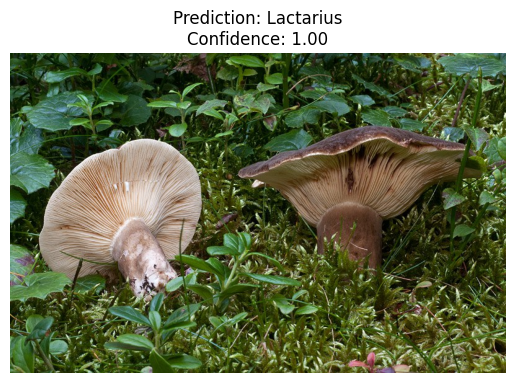

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from sklearn.preprocessing import LabelEncoder

# Load the trained model
model = load_model("mushroom_classifier_model_with_non_mushrooms.h5")

# Define the image path and preprocess it
image_path = "C:\\Users\\lalde\\laldeomaroam\\To_predict\\3.jpg"  # Image path
new_image = cv2.imread(image_path)  # Read the image
if new_image is None:
    print("Error: Unable to load image.")
else:
    # Preprocess the image
    new_image_resized = cv2.resize(new_image, (128, 128)) / 255.0  # Resize and normalize
    new_image_input = np.expand_dims(new_image_resized, axis=0)  # Add batch dimension

    # Make predictions
    prediction = model.predict(new_image_input)
    predicted_label = label_encoder.inverse_transform([np.argmax(prediction)])
    predicted_probability = np.max(prediction)

    # Display the image and prediction
    plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for display
    plt.axis('off')  # Remove axis
    plt.title(f"Prediction: {predicted_label[0]}\nConfidence: {predicted_probability:.2f}")
    plt.show()
